In [2]:
import matplotlib.pyplot as plt
import pandas as pd

df=pd.read_csv("food.csv")
print(df)
df.head()

          Date Food_Item   Category  Quantity  Price
0   2022-02-15     Pizza  Fast Food        12    250
1   2022-05-21    Burger  Fast Food        18    150
2   2022-09-10     Pasta    Italian        10    220
3   2023-01-12  Sandwich      Snack        15    120
4   2023-03-08     Fries      Snack        20    100
5   2023-06-18     Pizza  Fast Food        14    250
6   2023-08-25    Burger  Fast Food        16    150
7   2023-11-05     Pasta    Italian        11    220
8   2024-01-20     Fries      Snack        19    100
9   2024-03-15     Pizza  Fast Food        13    250
10  2024-05-27  Sandwich      Snack        17    120
11  2024-07-09    Burger  Fast Food        15    150
12  2024-09-14     Pizza  Fast Food        18    250
13  2024-11-30     Pasta    Italian        12    220
14  2025-01-11     Fries      Snack        21    100
15  2025-02-22     Pizza  Fast Food        20    250
16  2025-04-06    Burger  Fast Food        14    150
17  2025-06-19  Sandwich      Snack        16 

,Date,Food_Item,Category,Quantity,Price
0,2022-02-15,Pizza,Fast Food,12,250
1,2022-05-21,Burger,Fast Food,18,150
2,2022-09-10,Pasta,Italian,10,220
3,2023-01-12,Sandwich,Snack,15,120
4,2023-03-08,Fries,Snack,20,100


1. find total sales ?

In [3]:
df["Total_Sales"] = df["Quantity"] * df["Price"]
print(df["Total_Sales"])

0     3000
1     2700
2     2200
3     1800
4     2000
5     3500
6     2400
7     2420
8     1900
9     3250
10    2040
11    2250
12    4500
13    2640
14    2100
15    5000
16    2100
17    1920
18    2860
19    2200
Name: Total_Sales, dtype: int64


2. Food item wise total sales

In [4]:
food_sales = df.groupby("Food_Item")["Total_Sales"].sum()
print(food_sales)

Food_Item
Burger       9450
Fries        8200
Pasta       10120
Pizza       19250
Sandwich     5760
Name: Total_Sales, dtype: int64


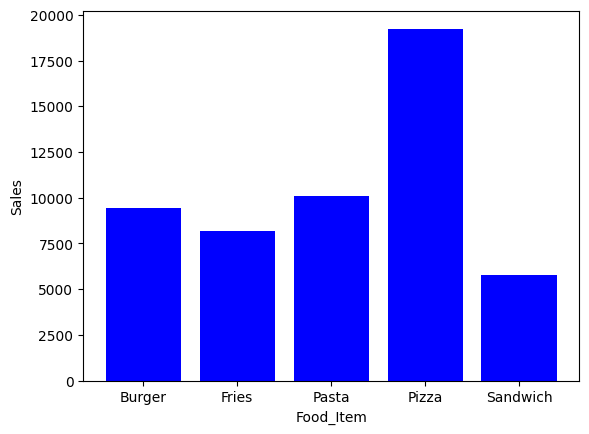

In [5]:
plt.Figure(figsize=(7,7))
plt.bar(food_sales.index, food_sales.values, color="blue")

plt.xlabel("Food_Item")
plt.ylabel("Sales")
plt.show()

3. date wsie sales trend


In [ ]:

date_sales=df.groupby("Date")["Total_Sales"].sum()
print(date_sales)

Date
2022-02-15    3000
2022-05-21    2700
2022-09-10    2200
2023-01-12    1800
2023-03-08    2000
2023-06-18    3500
2023-08-25    2400
2023-11-05    2420
2024-01-20    1900
2024-03-15    3250
2024-05-27    2040
2024-07-09    2250
2024-09-14    4500
2024-11-30    2640
2025-01-11    2100
2025-02-22    5000
2025-04-06    2100
2025-06-19    1920
2025-08-28    2860
2025-12-10    2200
Name: Total_Sales, dtype: int64


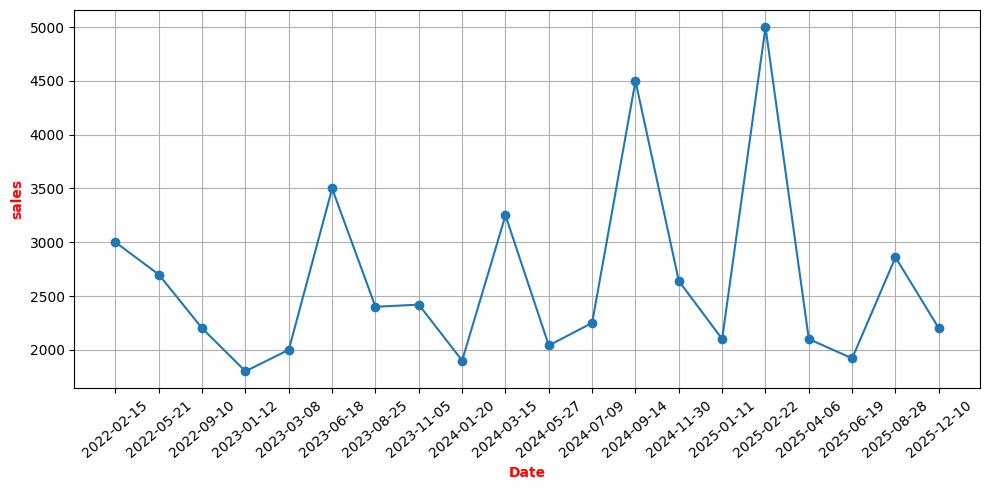

In [52]:
plt.figure(figsize=(10,5))
plt.plot(date_sales.index , date_sales.values,marker="o")
plt.grid(True)
plt.xlabel("Date",color="red",fontweight="bold")
plt.ylabel("sales",color="red",fontweight="bold")
plt.xticks(rotation=40)  
plt.tight_layout()
plt.show()

4.  Which food category had the highest sales  

In [8]:
category_sales=df.groupby("Category")["Total_Sales"].sum()
print(category_sales)

Category
Fast Food    28700
Italian      10120
Snack        13960
Name: Total_Sales, dtype: int64


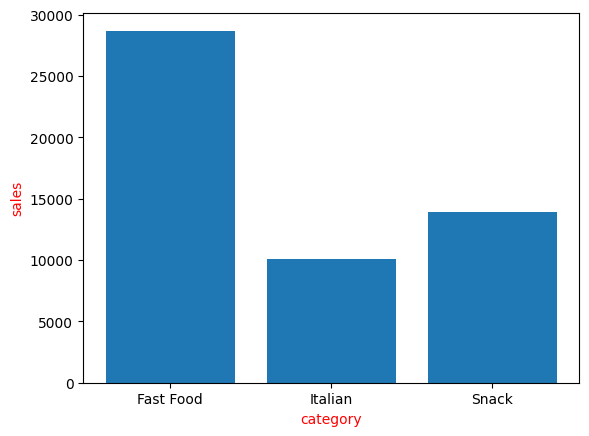

In [9]:
plt.bar(category_sales.index,category_sales.values)
plt.xlabel("category",color="red")
plt.ylabel("sales",color="red")
plt.show()

5. which food item had highest price or highest quantity

In [10]:
food_price=df.groupby("Food_Item")["Price"].max()
print(food_price)

quantity_sales=df.groupby("Food_Item")["Quantity"].max()
print(quantity_sales)

Food_Item
Burger      150
Fries       100
Pasta       220
Pizza       250
Sandwich    120
Name: Price, dtype: int64
Food_Item
Burger      18
Fries       22
Pasta       13
Pizza       20
Sandwich    17
Name: Quantity, dtype: int64


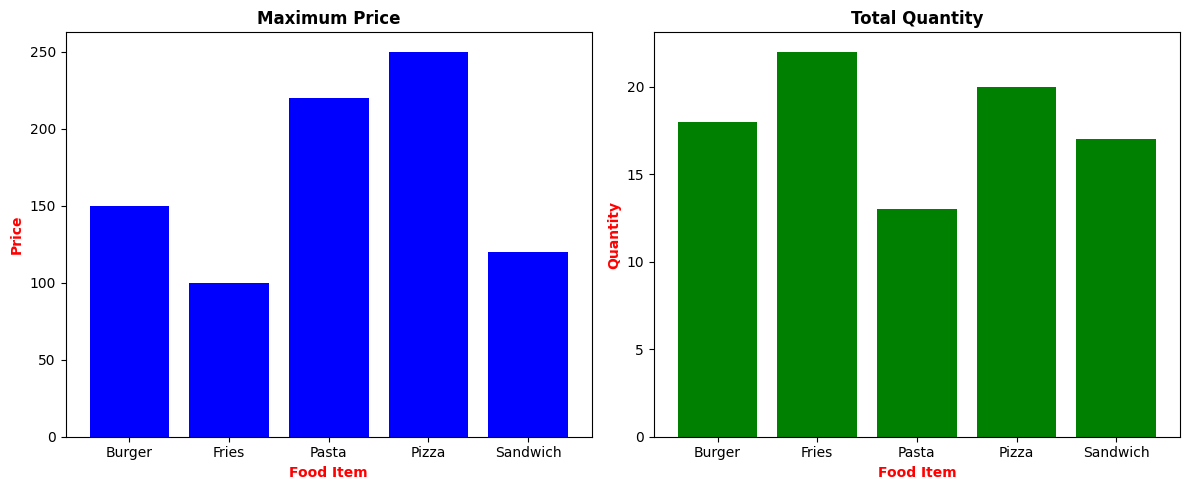

In [22]:
plt.figure(figsize=(12,5))

# First subplot
plt.subplot(1,2,1)
plt.bar(food_price.index, food_price.values, color="blue")
plt.title("Maximum Price",fontweight="black")
plt.xlabel("Food Item",color="red",fontweight="black")
plt.ylabel("Price",color="red",fontweight="black")

# Second subplot
plt.subplot(1,2,2)
plt.bar(quantity_sales.index, quantity_sales.values, color="green")
plt.title("Total Quantity",fontweight="black")
plt.xlabel("Food Item",color="Red",fontweight="black")
plt.ylabel("Quantity",color="red",fontweight="black")

plt.tight_layout() # proper spacing between graphs
plt.show()


6 . Average sales price of each Food Item

In [11]:
avg_sales=df.groupby("Food_Item")["Total_Sales"].mean()
print(avg_sales)

Food_Item
Burger      2362.5
Fries       2050.0
Pasta       2530.0
Pizza       3850.0
Sandwich    1920.0
Name: Total_Sales, dtype: float64


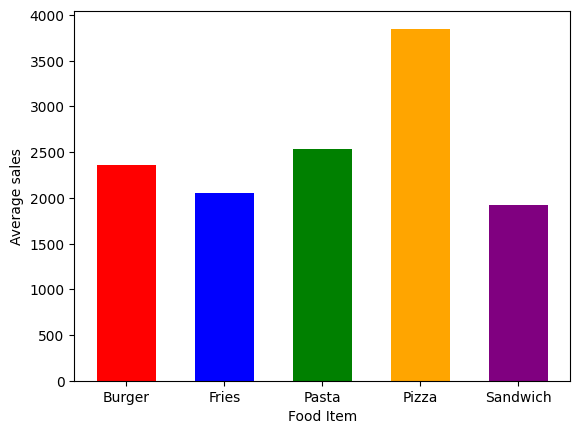

In [43]:
plt.bar(avg_sales.index,avg_sales.values,width=0.6,color=["red", "blue", "green", "orange", "purple"])
plt.xlabel("Food Item")
plt.ylabel("Average sales")
plt.show()

Which year had the highest sales?


In [13]:
df["Date"]=pd.to_datetime(df["Date"])
year_sales=df.groupby(df["Date"].dt.year)["Total_Sales"].sum()
print(year_sales)

Date
2022     7900
2023    12120
2024    16580
2025    16180
Name: Total_Sales, dtype: int64


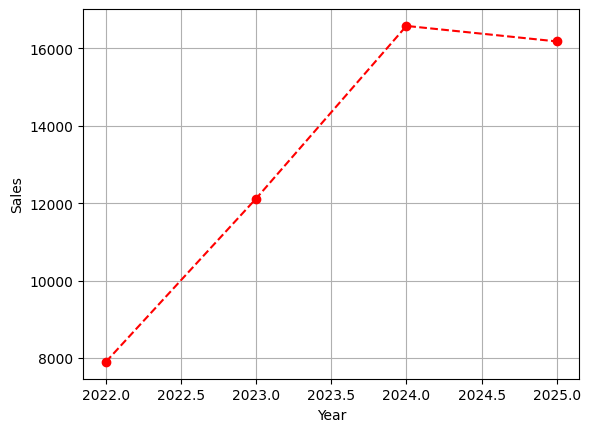

In [57]:
plt.plot(year_sales.index,year_sales.values,marker='o',linestyle="--",color="red")
plt.grid(True)
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

7. What is the total quantity sold each year?

In [27]:
total_quant=df.groupby(df["Date"].dt.year)["Quantity"].sum()
print(total_quant)

Date
2022     40
2023     76
2024     94
2025    106
Name: Quantity, dtype: int64


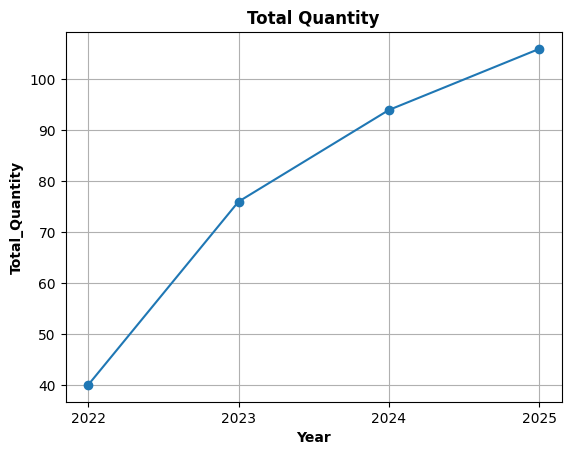

In [32]:
plt.plot(total_quant.index,total_quant.values,marker="o")
plt.grid(True)
plt.title("Total Quantity",fontweight="black")
plt.xlabel("Year",fontweight="black")
plt.ylabel("Total_Quantity",fontweight="black")
plt.xticks(total_quant.index)
plt.show()